In [73]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
import ROOT
import ctypes
import sys
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style") 
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

from matplotlib.ticker import ScalarFormatter


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
from math import sqrt

# Error-weighted combination function
def combine_error_weighted(x, y, x_err, y_err):
    central_value = (x / x_err**2 + y / y_err**2) / (1 / x_err**2 + 1 / y_err**2)
    error = 1 / sqrt(1 / x_err**2 + 1 / y_err**2)
    return central_value, error

In [75]:
def combine_x_plus_y_divided_by_2(x, y, x_err, y_err):
    central_value = (x+y)/2
    error = sqrt(x_err**2 +  y_err**2)/2
    return central_value, error

In [76]:
def correct_Acp_stats( Araw, Araw_err, Aref, Aref_err, Aref_pdg, Aref_K_mix):
    final_Acp = Araw - Aref + Aref_pdg + Aref_K_mix
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

In [77]:
def correct_Acp_stats_no_Kmix( Araw, Araw_err, Aref, Aref_err, Aref_pdg):
    final_Acp = Araw - Aref + Aref_pdg 
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

In [78]:
def delta_Acp_sys_unc(A_original, A_original_error, A, A_error):
    delta_Acp = A - A_original
    if A_original_error > A_error:
        delta_Acp_error = sqrt(A_original_error**2 - A_error**2)
    elif A_original_error < A_error:
        delta_Acp_error = sqrt(A_error**2 - A_original_error**2)
    elif A_original_error == A_error:
        delta_Acp_error = 0
    else: 
        print("Error: unable to proceed.")
        sys.exit()

    # print(f"delta_Acp: {delta_Acp}, delta_Acp_error: {delta_Acp_error}")
    print(f"Original Acp: {A_original * 100:.5f}%, Original Acp error: {A_original_error * 100:.5f}%")
    print(f"Acp: {A * 100:.5f}%, Acp error: {A_error * 100:.5f}%")
    print(f"delta_Acp: {delta_Acp * 100:.5f}%, delta_Acp_error: {delta_Acp_error * 100:.5f}%")
    return delta_Acp, delta_Acp_error

# MC15 full

## Acp(D+_(s) -> eta pi+)

### eta -> gg

In [79]:
#fitv3
Aref_gg_cms_plus = -0.00495716868227114 
Aref_gg_cms_plus_error = 0.0012428556744885479
Aref_gg_cms_minus = 0.009190873073308792
Aref_gg_cms_minus_error =  0.001354329439157585
Aref_gg_orginal, Aref_gg_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg_orginal: {Aref_gg_orginal}, Aref_gg_stats_error_orginal: {Aref_gg_stats_error_orginal}")

Aref_gg_orginal: 0.0021168521955188258, Aref_gg_stats_error_orginal: 0.0009190890132867003


In [80]:
# Acp params intro. mean
float_var = "mean"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_mean_plus: -2.2907736985100513e-07 pm 3.3935959159497125e-06
A_float_var_mean_minus: -3.6573621375879384e-06 pm 3.496443509284027e-06
Aref_gg: 0.0021220792520896814, Aref_gg_stats_error: 0.0009190798824667386
Original Acp: 0.21169%, Original Acp error: 0.09191%
Acp: 0.21221%, Acp error: 0.09191%
delta_Acp: 0.00052%, delta_Acp_error: 0.00041%


(5.227056570855648e-06, 4.096826728857937e-06)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 2.04305e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.9573e-03 +/-  1.24e-03
               Acp_bkg   -1.7919e-02 +/-  4.00e-03
              Acp_mean   -2.2908e-07 +/-  3.39e-06
               N_total    7.2879e+05 +/-  1.34e+03
            Nbkg_total    1.1328e+05 +/-  1.09e+03
                 delta    6.1155e-01 +/-  1.05e-02
                 gamma    7.1573e-02 +/-  3.29e-03
             mean_plus    1.8702e+00 +/-  1.38e-05
                 sigma    1.5309e-03 +/-  5.65e-05
           sigma_gauss    3.0268e-03 +/-  2.98e-05
            x_bkg1_tau   -5.9250e+00 +/-  1.16e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 0.000113098
                covariance matrix qual

In [81]:
# Acp params intro. delta
float_var = "delta"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )
A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")
print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_delta_plus: -0.002356743912594328 pm 0.001918747108344019
A_float_var_delta_minus: -0.0012939033803134325 pm 0.0021740755615898945
Aref_gg: 0.00262573119182824, Aref_gg_stats_error: 0.0010035417475298051
Original Acp: 0.21169%, Original Acp error: 0.09191%
Acp: 0.26257%, Acp error: 0.10035%
delta_Acp: 0.05089%, delta_Acp_error: 0.04030%


(0.0005088789963094142, 0.0004029533778129361)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 1.18621e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.3027e-03 +/-  1.35e-03
               Acp_bkg   -2.2130e-02 +/-  5.27e-03
             Acp_delta   -2.3567e-03 +/-  1.92e-03
               N_total    7.2877e+05 +/-  1.34e+03
            Nbkg_total    1.1329e+05 +/-  1.09e+03
            delta_plus    6.1023e-01 +/-  1.06e-02
                 gamma    7.1595e-02 +/-  3.29e-03
                  mean    1.8702e+00 +/-  1.23e-05
                 sigma    1.5315e-03 +/-  5.65e-05
           sigma_gauss    3.0266e-03 +/-  2.98e-05
            x_bkg1_tau   -5.9235e+00 +/-  1.16e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 1.71924e-05
                covariance matrix qual

In [82]:
# Acp params intro. gamma
float_var = "gamma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )
A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")
print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_gamma_plus: -0.00026200920314622955 pm 0.02345923244687244
A_float_var_gamma_minus: 0.01136985473593266 pm 0.021470868587732422
Aref_gg: 0.0021284637959981256, Aref_gg_stats_error: 0.0009195384653110084
Original Acp: 0.21169%, Original Acp error: 0.09191%
Acp: 0.21285%, Acp error: 0.09195%
delta_Acp: 0.00116%, delta_Acp_error: 0.00287%


(1.1611600479299877e-05, 2.874673620090185e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 3.88565e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.9586e-03 +/-  1.24e-03
               Acp_bkg   -1.7930e-02 +/-  4.00e-03
             Acp_gamma   -2.6201e-04 +/-  2.35e-02
               N_total    7.2879e+05 +/-  1.34e+03
            Nbkg_total    1.1328e+05 +/-  1.09e+03
                 delta    6.1156e-01 +/-  1.05e-02
            gamma_plus    7.1559e-02 +/-  3.70e-03
                  mean    1.8702e+00 +/-  1.23e-05
                 sigma    1.5310e-03 +/-  5.64e-05
           sigma_gauss    3.0267e-03 +/-  2.98e-05
            x_bkg1_tau   -5.9247e+00 +/-  1.16e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 5.0978e-06
                covariance matrix quali

In [83]:
# Acp params intro. sigma
float_var = "sigma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )
A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")
print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_sigma_plus: 0.003252062933108757 pm 0.0031924361288830916
A_float_var_sigma_minus: 0.0007186826136418301 pm 0.0037966728210091193
Aref_gg: 0.002325745655178457, Aref_gg_stats_error: 0.0009532860987120355
Original Acp: 0.21169%, Original Acp error: 0.09191%
Acp: 0.23257%, Acp error: 0.09533%
delta_Acp: 0.02089%, delta_Acp_error: 0.02530%


(0.00020889345965963146, 0.00025304104736839124)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 0.000132654
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.6121e-03 +/-  1.29e-03
               Acp_bkg   -2.0138e-02 +/-  4.55e-03
             Acp_sigma    3.2521e-03 +/-  3.19e-03
               N_total    7.2879e+05 +/-  1.34e+03
            Nbkg_total    1.1328e+05 +/-  1.09e+03
                 delta    6.1149e-01 +/-  1.05e-02
                 gamma    7.1598e-02 +/-  3.29e-03
                  mean    1.8702e+00 +/-  1.23e-05
           sigma_gauss    3.0271e-03 +/-  2.98e-05
            sigma_plus    1.5355e-03 +/-  5.67e-05
            x_bkg1_tau   -5.9242e+00 +/-  1.16e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 1.48761e-05
                covariance matrix qual

In [84]:
# Acp params intro. sigma_gauss
float_var = "sigma_gauss"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )
A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")
print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")
delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_sigma_gauss_plus: -0.0007161552279182359 pm 0.002450165777241373
A_float_var_sigma_gauss_minus: -0.0019156988141133535 pm 0.002487009160579514
Aref_gg: 0.0020815675558649716, Aref_gg_stats_error: 0.000920430191958611
Original Acp: 0.21169%, Original Acp error: 0.09191%
Acp: 0.20816%, Acp error: 0.09204%
delta_Acp: -0.00353%, delta_Acp_error: 0.00497%


(-3.52846396538542e-05, 4.967015124443588e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 0.000121271
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.9741e-03 +/-  1.24e-03
               Acp_bkg   -1.7787e-02 +/-  4.02e-03
       Acp_sigma_gauss   -7.1616e-04 +/-  2.45e-03
               N_total    7.2879e+05 +/-  1.34e+03
            Nbkg_total    1.1328e+05 +/-  1.09e+03
                 delta    6.1157e-01 +/-  1.05e-02
                 gamma    7.1563e-02 +/-  3.29e-03
                  mean    1.8702e+00 +/-  1.23e-05
                 sigma    1.5310e-03 +/-  5.64e-05
      sigma_gauss_plus    3.0246e-03 +/-  3.07e-05
            x_bkg1_tau   -5.9243e+00 +/-  1.16e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 2.44271e-05
                covariance matrix qual

In [85]:
# Acp params intro. x_bkg1_tau
float_var = "x_bkg1_tau"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )
A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")
print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")
delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_x_bkg1_tau_plus: 0.004023983878072457 pm 0.015552959321019303
A_float_var_x_bkg1_tau_minus: -0.00415768286217677 pm 0.020563796516068218
Aref_gg: 0.002122897558302861, Aref_gg_stats_error: 0.0009221351575440973
Original Acp: 0.21169%, Original Acp error: 0.09191%
Acp: 0.21229%, Acp error: 0.09221%
delta_Acp: 0.00060%, delta_Acp_error: 0.00749%


(6.045362784035113e-06, 7.489081675717513e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 4.8676e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.9277e-03 +/-  1.25e-03
               Acp_bkg   -1.8100e-02 +/-  4.06e-03
        Acp_x_bkg1_tau    4.0240e-03 +/-  1.56e-02
               N_total    7.2879e+05 +/-  1.34e+03
            Nbkg_total    1.1327e+05 +/-  1.09e+03
                 delta    6.1153e-01 +/-  1.05e-02
                 gamma    7.1569e-02 +/-  3.29e-03
                  mean    1.8702e+00 +/-  1.23e-05
                 sigma    1.5308e-03 +/-  5.65e-05
           sigma_gauss    3.0268e-03 +/-  2.98e-05
       x_bkg1_tau_plus   -5.9494e+00 +/-  1.50e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 6.87183e-06
                covariance matrix quali

## Acp(D+_(s) -> eta pi+)

### eta -> pipipi

In [86]:
Aref_pipipi_cms_plus = -0.005620825562001497
Aref_pipipi_cms_plus_error = 0.0011461459010934164
Aref_pipipi_cms_minus =  0.009010943177567787
Aref_pipipi_cms_minus_error = 0.0012540251077938882
Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi_orginal: {Aref_pipipi_orginal}, Aref_pipipi_stats_error_orginal: {Aref_pipipi_stats_error_orginal}")

Aref_pipipi_orginal: 0.0016950588077831452, Aref_pipipi_stats_error_orginal: 0.0008494453186595816


In [87]:
# Acp params intro. mean
float_var = "mean"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_mean_plus: -2.4503005795484256e-06 pm 3.1606066208117296e-06
A_float_var_mean_minus: -5.230494980468237e-06 pm 3.2683670242625744e-06
Aref_pipipi: 0.001701534721124276, Aref_pipipi_stats_error: 0.0008494676664815735
Original Acp: 0.16951%, Original Acp error: 0.08494%
Acp: 0.17015%, Acp error: 0.08495%
delta_Acp: 0.00065%, delta_Acp_error: 0.00062%


(6.475913341130735e-06, 6.161737171589039e-06)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 8.21166e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.6186e-03 +/-  1.15e-03
               Acp_bkg   -1.2860e-02 +/-  2.94e-03
              Acp_mean   -2.4503e-06 +/-  3.16e-06
               N_total    8.8336e+05 +/-  1.65e+03
            Nbkg_total    1.9859e+05 +/-  1.43e+03
                 delta    5.9777e-01 +/-  1.03e-02
                 gamma    6.5803e-02 +/-  3.16e-03
             mean_plus    1.8701e+00 +/-  1.30e-05
                 sigma    1.5176e-03 +/-  5.51e-05
           sigma_gauss    3.0403e-03 +/-  2.89e-05
            x_bkg1_tau   -4.6238e+00 +/-  8.20e-02


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 0.000145134
                covariance matrix qual

In [88]:
# Acp params intro. delta
float_var = "delta"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_delta_plus: -0.001998481196800017 pm 0.0019170247845755198
A_float_var_delta_minus: -0.0023937202976646033 pm 0.002165276332626397
Aref_pipipi: 0.0023777332153940844, Aref_pipipi_stats_error: 0.0009604973209048324
Original Acp: 0.16951%, Original Acp error: 0.08494%
Acp: 0.23777%, Acp error: 0.09605%
delta_Acp: 0.06827%, delta_Acp_error: 0.04483%


(0.0006826744076109392, 0.0004483277306532382)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 3.5031e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.9995e-03 +/-  1.29e-03
               Acp_bkg   -1.5608e-02 +/-  3.95e-03
             Acp_delta   -1.9985e-03 +/-  1.92e-03
               N_total    8.8336e+05 +/-  1.66e+03
            Nbkg_total    1.9859e+05 +/-  1.44e+03
            delta_plus    5.9651e-01 +/-  1.04e-02
                 gamma    6.5763e-02 +/-  3.16e-03
                  mean    1.8701e+00 +/-  1.16e-05
                 sigma    1.5172e-03 +/-  5.53e-05
           sigma_gauss    3.0406e-03 +/-  2.90e-05
            x_bkg1_tau   -4.6244e+00 +/-  8.21e-02


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 9.91916e-05
                covariance matrix quali

In [89]:
# Acp params intro. gamma
float_var = "gamma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_gamma_plus: 0.0011481347159472133 pm 0.023799237311150225
A_float_var_gamma_minus: 0.03465511596414905 pm 0.02169239237723527
Aref_pipipi: 0.0017260493651473086, Aref_pipipi_stats_error: 0.0008497044369384225
Original Acp: 0.16951%, Original Acp error: 0.08494%
Acp: 0.17260%, Acp error: 0.08497%
delta_Acp: 0.00310%, delta_Acp_error: 0.00210%


(3.099055736416334e-05, 2.0982868253971e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 5.46931e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.6180e-03 +/-  1.15e-03
               Acp_bkg   -1.2859e-02 +/-  2.94e-03
             Acp_gamma    1.1481e-03 +/-  2.38e-02
               N_total    8.8336e+05 +/-  1.61e+03
            Nbkg_total    1.9859e+05 +/-  1.38e+03
                 delta    5.9777e-01 +/-  9.68e-03
            gamma_plus    6.5855e-02 +/-  3.51e-03
                  mean    1.8701e+00 +/-  1.16e-05
                 sigma    1.5176e-03 +/-  5.15e-05
           sigma_gauss    3.0404e-03 +/-  2.71e-05
            x_bkg1_tau   -4.6240e+00 +/-  8.15e-02


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 2.60222e-06
                covariance matrix qual

In [90]:
# Acp params intro. sigma
float_var = "sigma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_sigma_plus: 0.0014562688368515708 pm 0.003081410731633157
A_float_var_sigma_minus: 0.0025142806683078334 pm 0.003616970119171597
Aref_pipipi: 0.0019290871879395488, Aref_pipipi_stats_error: 0.0008945127159707536
Original Acp: 0.16951%, Original Acp error: 0.08494%
Acp: 0.19291%, Acp error: 0.08945%
delta_Acp: 0.02340%, delta_Acp_error: 0.02803%


(0.0002340283801564036, 0.0002803491566612891)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 1.28711e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.4449e-03 +/-  1.21e-03
               Acp_bkg   -1.3634e-02 +/-  3.37e-03
             Acp_sigma    1.4563e-03 +/-  3.08e-03
               N_total    8.8337e+05 +/-  1.65e+03
            Nbkg_total    1.9858e+05 +/-  1.43e+03
                 delta    5.9767e-01 +/-  1.03e-02
                 gamma    6.5776e-02 +/-  3.16e-03
                  mean    1.8701e+00 +/-  1.16e-05
           sigma_gauss    3.0407e-03 +/-  2.88e-05
            sigma_plus    1.5193e-03 +/-  5.51e-05
            x_bkg1_tau   -4.6243e+00 +/-  8.20e-02


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 7.3988e-06
                covariance matrix quali

In [91]:
# Acp params intro. sigma_gauss
float_var = "sigma_gauss"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_sigma_gauss_plus: -0.0033144139221432667 pm 0.002283085120549855
A_float_var_sigma_gauss_minus: -0.0005833460365386456 pm 0.0023543560587921393
Aref_pipipi: 0.0016245569218726885, Aref_pipipi_stats_error: 0.0008515476500071075
Original Acp: 0.16951%, Original Acp error: 0.08494%
Acp: 0.16246%, Acp error: 0.08515%
delta_Acp: -0.00705%, delta_Acp_error: 0.00598%


(-7.05018859104567e-05, 5.980009063495817e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 0.000109215
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.7410e-03 +/-  1.15e-03
               Acp_bkg   -1.2304e-02 +/-  2.96e-03
       Acp_sigma_gauss   -3.3144e-03 +/-  2.28e-03
               N_total    8.8336e+05 +/-  1.65e+03
            Nbkg_total    1.9859e+05 +/-  1.43e+03
                 delta    5.9784e-01 +/-  1.03e-02
                 gamma    6.5756e-02 +/-  3.16e-03
                  mean    1.8701e+00 +/-  1.16e-05
                 sigma    1.5180e-03 +/-  5.49e-05
      sigma_gauss_plus    3.0299e-03 +/-  2.97e-05
            x_bkg1_tau   -4.6239e+00 +/-  8.20e-02


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 1.03823e-05
                covariance matrix qual

In [92]:
# Acp params intro. x_bkg1_tau
float_var = "x_bkg1_tau"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_1ab_Kspip_pipipi_fit_opt_loose_v7_fitv3_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_x_bkg1_tau_plus: -0.019744860643597928 pm 0.014483834517235353
A_float_var_x_bkg1_tau_minus: 0.0015633889670390033 pm 0.020457511074179553
Aref_pipipi: 0.0016381106721679584, Aref_pipipi_stats_error: 0.0008515591559030089
Original Acp: 0.16951%, Original Acp error: 0.08494%
Acp: 0.16381%, Acp error: 0.08516%
delta_Acp: -0.00569%, delta_Acp_error: 0.00600%


(-5.694813561518686e-05, 5.996371077215772e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 1.03379e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.7434e-03 +/-  1.15e-03
               Acp_bkg   -1.2299e-02 +/-  2.97e-03
        Acp_x_bkg1_tau   -1.9745e-02 +/-  1.45e-02
               N_total    8.8336e+05 +/-  1.65e+03
            Nbkg_total    1.9859e+05 +/-  1.43e+03
                 delta    5.9778e-01 +/-  1.03e-02
                 gamma    6.5797e-02 +/-  3.16e-03
                  mean    1.8701e+00 +/-  1.16e-05
                 sigma    1.5176e-03 +/-  5.48e-05
           sigma_gauss    3.0404e-03 +/-  2.88e-05
       x_bkg1_tau_plus   -4.5313e+00 +/-  1.06e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 9.00299e-05
                covariance matrix qual

## Acp(D+_(s) -> eta K+)

### eta -> gg

In [156]:
#fitv3
Aref_gg_cms_plus = -0.000891053282276677
Aref_gg_cms_plus_error = 0.002591316856349276
Aref_gg_cms_minus = 0.01696678351479708
Aref_gg_cms_minus_error = 0.002695345787618729
Aref_gg_orginal, Aref_gg_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg_orginal: {Aref_gg_orginal}, Aref_gg_stats_error_orginal: {Aref_gg_stats_error_orginal}")

Aref_gg_orginal: 0.008037865116260201, Aref_gg_stats_error_orginal: 0.0018694793369300662


In [157]:
# Acp params intro. mean
float_var = "mean"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_mean_plus: 1.3405628069840247e-06 pm 6.145718534045529e-06
A_float_var_mean_minus: 4.530883010556153e-06 pm 5.841394002540936e-06
Aref_gg: 0.008036746153860796, Aref_gg_stats_error: 0.0018694653200113625
Original Acp: 0.80379%, Original Acp error: 0.18695%
Acp: 0.80367%, Acp error: 0.18695%
delta_Acp: -0.00011%, delta_Acp_error: 0.00072%


(-1.118962399404566e-06, 7.239370365829966e-06)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 255.048
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -8.8816e-04 +/-  2.59e-03
               Acp_bkg   -3.3576e-02 +/-  8.32e-03
              Acp_mean    1.3406e-06 +/-  6.15e-06
               N_total    1.8874e+05 +/-  8.36e+02
            Nbkg_total    2.7342e+04 +/-  7.07e+02
                 delta    5.9563e-01 +/-  2.59e-02
                 gamma   -6.7301e-04 +/-  6.90e-03
             mean_plus    1.9687e+00 +/-  2.56e-05
                 sigma    1.3047e-03 +/-  1.20e-04
           sigma_gauss    2.8188e-03 +/-  5.89e-05
            x_bkg1_tau   -2.2159e+00 +/-  2.29e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 141.05
                covariance matrix quality: Full

In [158]:
# Acp params intro. delta
float_var = "delta"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")
delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_delta_plus: 0.001419542569927934 pm 0.004164811647581074
A_float_var_delta_minus: 0.0036380164910323476 pm 0.004008711707619325
Aref_gg: 0.007465357191679234, Aref_gg_stats_error: 0.00200596790304013
Original Acp: 0.80379%, Original Acp error: 0.18695%
Acp: 0.74654%, Acp error: 0.20060%
delta_Acp: -0.05725%, delta_Acp_error: 0.07273%


(-0.0005725079245809672, 0.0007272924011831399)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 254.741
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -1.2786e-03 +/-  2.85e-03
               Acp_bkg   -3.0885e-02 +/-  1.14e-02
             Acp_delta    1.4195e-03 +/-  4.16e-03
               N_total    1.8875e+05 +/-  8.33e+02
            Nbkg_total    2.7339e+04 +/-  7.04e+02
            delta_plus    5.9639e-01 +/-  2.62e-02
                 gamma   -6.1542e-04 +/-  6.90e-03
                  mean    1.9687e+00 +/-  2.26e-05
                 sigma    1.3043e-03 +/-  1.19e-04
           sigma_gauss    2.8189e-03 +/-  5.84e-05
            x_bkg1_tau   -2.2147e+00 +/-  2.29e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 140.771
                covariance matrix quality: Ful

In [162]:
# Acp params intro. gamma
float_var = "gamma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")
delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_gamma_plus: 0.7459201796526682 pm 2.384454877725299
A_float_var_gamma_minus: -0.4332462662664116 pm 0.7633220813729106
Aref_gg: 0.008001524268535176, Aref_gg_stats_error: 0.002293196551171362
Original Acp: 0.80379%, Original Acp error: 0.18695%
Acp: 0.80015%, Acp error: 0.22932%
delta_Acp: -0.00363%, delta_Acp_error: 0.13281%


(-3.634084772502488e-05, 0.0013280803556621676)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 1560.9
                covariance matrix quality: Full matrix, but forced positive-definite
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -9.0598e-04 +/-  3.47e-03
               Acp_bkg   -3.3470e-02 +/-  1.28e-02
             Acp_gamma    7.4592e-01 +/-  2.38e+00
               N_total    1.8875e+05 +/-  5.78e+03
            Nbkg_total    2.7333e+04 +/-  5.74e+03
                 delta    5.9529e-01 +/-  2.70e-01
            gamma_plus   -4.3865e-03 +/-  1.14e-02
                  mean    1.9687e+00 +/-  2.35e-05
                 sigma    1.3032e-03 +/-  1.32e-03
           sigma_gauss    2.8195e-03 +/-  6.58e-04
            x_bkg1_tau   -2.2406e+00 +/-  8.84e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 356.103
                covariance matrix qual

In [163]:
# Acp params intro. sigma
float_var = "sigma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")
delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_sigma_plus: -0.0043801072664566565 pm 0.006889578216161785
A_float_var_sigma_minus: -0.008436222185074116 pm 0.007983696712769151
Aref_gg: 0.007539293926541346, Aref_gg_stats_error: 0.0019218226821631319
Original Acp: 0.80379%, Original Acp error: 0.18695%
Acp: 0.75393%, Acp error: 0.19218%
delta_Acp: -0.04986%, delta_Acp_error: 0.04455%


(-0.0004985711897188549, 0.00044547663290930807)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 255.06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -1.3250e-03 +/-  2.69e-03
               Acp_bkg   -3.0546e-02 +/-  9.52e-03
             Acp_sigma   -4.3801e-03 +/-  6.89e-03
               N_total    1.8874e+05 +/-  7.79e+02
            Nbkg_total    2.7342e+04 +/-  6.40e+02
                 delta    5.9569e-01 +/-  2.20e-02
                 gamma   -6.4930e-04 +/-  6.88e-03
                  mean    1.9687e+00 +/-  2.25e-05
           sigma_gauss    2.8185e-03 +/-  4.87e-05
            sigma_plus    1.2994e-03 +/-  9.89e-05
            x_bkg1_tau   -2.2155e+00 +/-  2.24e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 140.803
                covariance matrix quality: Full

In [164]:
# Acp params intro. sigma_gauss
float_var = "sigma_gauss"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")
delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_sigma_gauss_plus: -0.005085847076131134 pm 0.004925694943054842
A_float_var_sigma_gauss_minus: -0.0026787488230409773 pm 0.0041908707715837485
Aref_gg: 0.007937854192629379, Aref_gg_stats_error: 0.0018711243217785138
Original Acp: 0.80379%, Original Acp error: 0.18695%
Acp: 0.79379%, Acp error: 0.18711%
delta_Acp: -0.01000%, delta_Acp_error: 0.00784%


(-0.0001000109236308222, 7.844256715982588e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 254.908
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -1.0344e-03 +/-  2.59e-03
               Acp_bkg   -3.2617e-02 +/-  8.36e-03
       Acp_sigma_gauss   -5.0858e-03 +/-  4.93e-03
               N_total    1.8875e+05 +/-  8.33e+02
            Nbkg_total    2.7342e+04 +/-  7.04e+02
                 delta    5.9549e-01 +/-  2.57e-02
                 gamma   -6.6762e-04 +/-  6.90e-03
                  mean    1.9687e+00 +/-  2.26e-05
                 sigma    1.3039e-03 +/-  1.19e-04
      sigma_gauss_plus    2.8048e-03 +/-  6.00e-05
            x_bkg1_tau   -2.2153e+00 +/-  2.29e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 140.799
                covariance matrix quality: Ful

In [165]:
# Acp params intro. x_bkg1_tau
float_var = "x_bkg1_tau"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")
delta_Acp_sys_unc(Aref_gg_orginal, Aref_gg_stats_error_orginal,Aref_gg, Aref_gg_stats_error)

A_float_var_x_bkg1_tau_plus: 0.002510724526152641 pm 0.08694014654416223
A_float_var_x_bkg1_tau_minus: -0.08271286842852854 pm 0.09965969183378416
Aref_gg: 0.007985957556467915, Aref_gg_stats_error: 0.0018720671921412754
Original Acp: 0.80379%, Original Acp error: 0.18695%
Acp: 0.79860%, Acp error: 0.18721%
delta_Acp: -0.00519%, delta_Acp_error: 0.00984%


(-5.1907559792285785e-05, 9.840010509770417e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 254.638
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -8.8570e-04 +/-  2.60e-03
               Acp_bkg   -3.3561e-02 +/-  8.34e-03
        Acp_x_bkg1_tau    2.5107e-03 +/-  8.69e-02
               N_total    1.8875e+05 +/-  7.79e+02
            Nbkg_total    2.7341e+04 +/-  6.40e+02
                 delta    5.9559e-01 +/-  2.20e-02
                 gamma   -6.9957e-04 +/-  6.87e-03
                  mean    1.9687e+00 +/-  2.25e-05
                 sigma    1.3046e-03 +/-  1.00e-04
           sigma_gauss    2.8188e-03 +/-  4.87e-05
       x_bkg1_tau_plus   -2.2226e+00 +/-  2.53e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 140.729
                covariance matrix quality: Ful

## Acp(D+_(s) -> eta K+)

### eta -> pipipi

In [166]:
#fitv3
Aref_pipipi_cms_plus = 0.00013218589725561003
Aref_pipipi_cms_plus_error = 0.002166365637515913
Aref_pipipi_cms_minus = 0.01753684985818671
Aref_pipipi_cms_minus_error = 0.0022719620271573465
Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi_orginal: {Aref_pipipi_orginal}, Aref_pipipi_stats_error_orginal: {Aref_pipipi_stats_error_orginal}")

Aref_pipipi_orginal: 0.00883451787772116, Aref_pipipi_stats_error_orginal: 0.001569629855113511


In [167]:
# Acp params intro. mean
float_var = "mean"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")
delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_mean_plus: -1.1960332857441358e-07 pm 5.2257259438585725e-06
A_float_var_mean_minus: 1.346674466828901e-06 pm 5.0047628745994e-06
Aref_pipipi: 0.008838365749111454, Aref_pipipi_stats_error: 0.0015696914563213058
Original Acp: 0.88345%, Original Acp error: 0.15696%
Acp: 0.88384%, Acp error: 0.15697%
delta_Acp: 0.00038%, delta_Acp_error: 0.00139%


(3.847871390294522e-06, 1.3906328934710977e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 381.08
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp    1.3724e-04 +/-  2.17e-03
               Acp_bkg   -2.1500e-02 +/-  5.50e-03
              Acp_mean   -1.1960e-07 +/-  5.23e-06
               N_total    2.7323e+05 +/-  1.20e+03
            Nbkg_total    5.8650e+04 +/-  1.08e+03
                 delta    5.4789e-01 +/-  2.14e-02
                 gamma    1.5438e-02 +/-  6.01e-03
             mean_plus    1.9688e+00 +/-  2.16e-05
                 sigma    1.1466e-03 +/-  9.29e-05
           sigma_gauss    2.9176e-03 +/-  4.48e-05
            x_bkg1_tau   -2.9250e+00 +/-  1.58e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 244.853
                covariance matrix quality: Full

In [168]:
# Acp params intro. delta
float_var = "delta"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")
delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_delta_plus: 0.0036934138456981014 pm 0.00396834499296263
A_float_var_delta_minus: -0.00016659503524296682 pm 0.003877495249735155
Aref_pipipi: 0.008296731018433479, Aref_pipipi_stats_error: 0.0017638747103015052
Original Acp: 0.88345%, Original Acp error: 0.15696%
Acp: 0.82967%, Acp error: 0.17639%
delta_Acp: -0.05378%, delta_Acp_error: 0.08047%


(-0.0005377868592876811, 0.0008046838581564549)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 381.76
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -9.9269e-04 +/-  2.51e-03
               Acp_bkg   -1.6255e-02 +/-  7.87e-03
             Acp_delta    3.6934e-03 +/-  3.97e-03
               N_total    2.7323e+05 +/-  1.27e+03
            Nbkg_total    5.8650e+04 +/-  1.16e+03
            delta_plus    5.5004e-01 +/-  2.45e-02
                 gamma    1.5461e-02 +/-  6.01e-03
                  mean    1.9688e+00 +/-  1.91e-05
                 sigma    1.1472e-03 +/-  1.05e-04
           sigma_gauss    2.9171e-03 +/-  5.12e-05
            x_bkg1_tau   -2.9244e+00 +/-  1.61e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 244.566
                covariance matrix quality: Full

In [169]:
# Acp params intro. gamma
float_var = "gamma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")
delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_gamma_plus: -0.15014274872299027 pm 0.2454281566484373
A_float_var_gamma_minus: -0.09305213885217678 pm 0.10416013871402394
Aref_pipipi: 0.008809648523113278, Aref_pipipi_stats_error: 0.0016625361226293134
Original Acp: 0.88345%, Original Acp error: 0.15696%
Acp: 0.88096%, Acp error: 0.16625%
delta_Acp: -0.00249%, delta_Acp_error: 0.05480%


(-2.4869354607881533e-05, 0.0005479858364808803)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 627.55
                covariance matrix quality: Full matrix, but forced positive-definite
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp    1.0966e-04 +/-  2.39e-03
               Acp_bkg   -2.1387e-02 +/-  6.35e-03
             Acp_gamma   -1.5014e-01 +/-  2.45e-01
               N_total    2.7324e+05 +/-  5.70e+03
            Nbkg_total    5.8646e+04 +/-  5.66e+03
                 delta    5.4782e-01 +/-  1.46e-01
            gamma_plus    1.3140e-02 +/-  3.53e-03
                  mean    1.9688e+00 +/-  2.51e-05
                 sigma    1.1462e-03 +/-  6.76e-04
           sigma_gauss    2.9177e-03 +/-  3.39e-04
            x_bkg1_tau   -2.9245e+00 +/-  4.20e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 517.63
                covariance matrix quali

In [170]:
# Acp params intro. sigma
float_var = "sigma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")
delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_sigma_plus: -0.008821784924772924 pm 0.006465601298546508
A_float_var_sigma_minus: -0.0009435717360954943 pm 0.00752413622328136
Aref_pipipi: 0.008310272679841912, Aref_pipipi_stats_error: 0.0016435000040362455
Original Acp: 0.88345%, Original Acp error: 0.15696%
Acp: 0.83103%, Acp error: 0.16435%
delta_Acp: -0.05242%, delta_Acp_error: 0.04872%


(-0.0005242451978792473, 0.0004871902925997989)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 381.685
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -8.4872e-04 +/-  2.29e-03
               Acp_bkg   -1.6921e-02 +/-  6.43e-03
             Acp_sigma   -8.8218e-03 +/-  6.47e-03
               N_total    2.7323e+05 +/-  1.20e+03
            Nbkg_total    5.8654e+04 +/-  1.08e+03
                 delta    5.4816e-01 +/-  2.13e-02
                 gamma    1.5462e-02 +/-  6.01e-03
                  mean    1.9688e+00 +/-  1.91e-05
           sigma_gauss    2.9167e-03 +/-  4.46e-05
            sigma_plus    1.1379e-03 +/-  9.05e-05
            x_bkg1_tau   -2.9241e+00 +/-  1.57e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 244.428
                covariance matrix quality: Ful

In [171]:
# Acp params intro. sigma_gauss
float_var = "sigma_gauss"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")
delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_sigma_gauss_plus: -0.008475177902392828 pm 0.003979551459013761
A_float_var_sigma_gauss_minus: -0.001755824903789338 pm 0.00353464682546497
Aref_pipipi: 0.008656906774098139, Aref_pipipi_stats_error: 0.0015721594018241608
Original Acp: 0.88345%, Original Acp error: 0.15696%
Acp: 0.86569%, Acp error: 0.15722%
delta_Acp: -0.01776%, delta_Acp_error: 0.00891%


(-0.00017761110362302102, 8.914764540043503e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 380.806
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -1.7388e-04 +/-  2.17e-03
               Acp_bkg   -2.0058e-02 +/-  5.54e-03
       Acp_sigma_gauss   -8.4752e-03 +/-  3.98e-03
               N_total    2.7324e+05 +/-  1.20e+03
            Nbkg_total    5.8648e+04 +/-  1.08e+03
                 delta    5.4789e-01 +/-  2.14e-02
                 gamma    1.5408e-02 +/-  6.01e-03
                  mean    1.9688e+00 +/-  1.91e-05
                 sigma    1.1466e-03 +/-  9.28e-05
      sigma_gauss_plus    2.8928e-03 +/-  4.62e-05
            x_bkg1_tau   -2.9253e+00 +/-  1.57e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 244.288
                covariance matrix quality: Ful

In [172]:
# Acp params intro. x_bkg1_tau
float_var = "x_bkg1_tau"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_plus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv3_Ds_train_Dp_CMS_p_Dp_CMS_minus_sumw2fixed_weighted_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")
delta_Acp_sys_unc(Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal, Aref_pipipi, Aref_pipipi_stats_error)

A_float_var_x_bkg1_tau_plus: 0.003963072263712286 pm 0.04224498728210323
A_float_var_x_bkg1_tau_minus: -0.07836868477647763 pm 0.048419862293460736
Aref_pipipi: 0.008766133015764788, Aref_pipipi_stats_error: 0.0015714090722054627
Original Acp: 0.88345%, Original Acp error: 0.15696%
Acp: 0.87661%, Acp error: 0.15714%
delta_Acp: -0.00684%, delta_Acp_error: 0.00748%


(-6.838486195637206e-05, 7.475687357007133e-05)


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 380.701
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp    1.4586e-04 +/-  2.17e-03
               Acp_bkg   -2.1554e-02 +/-  5.53e-03
        Acp_x_bkg1_tau    3.9631e-03 +/-  4.22e-02
               N_total    2.7324e+05 +/-  1.27e+03
            Nbkg_total    5.8647e+04 +/-  1.16e+03
                 delta    5.4785e-01 +/-  2.39e-02
                 gamma    1.5417e-02 +/-  6.01e-03
                  mean    1.9688e+00 +/-  1.91e-05
                 sigma    1.1464e-03 +/-  1.05e-04
           sigma_gauss    2.9177e-03 +/-  5.10e-05
       x_bkg1_tau_plus   -2.9371e+00 +/-  1.86e-01


  RooFitResult: minimized FCN value: 0, estimated distance to minimum: 244.255
                covariance matrix quality: Ful

Original Mean: 22.3
Bootstrap 95% Confidence Interval: (15.147499999999999, 29.252499999999998)


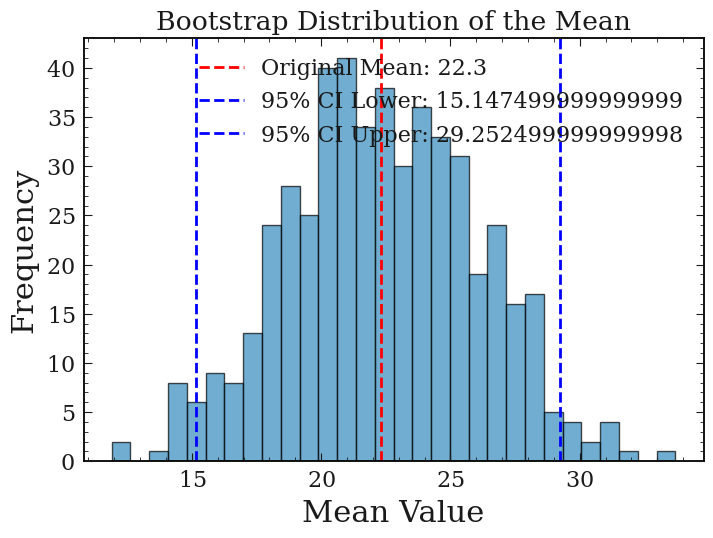

In [173]:
import numpy as np
import matplotlib.pyplot as plt

# Original dataset
# data = np.array([2, 4, 6, 8, 10])
data = np.array([5, 9, 12, 15, 19, 25, 30, 33, 35, 40])  # Example data

# Function to compute the mean of a dataset
def compute_mean(data):
    return np.mean(data)

# Number of bootstrap samples
n_bootstrap = 500

# Array to store means of bootstrap samples
bootstrap_means = []

# Bootstrap resampling
for _ in range(n_bootstrap):
    # Generate a bootstrap sample by sampling with replacement
    bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
    
    # Compute the mean of the bootstrap sample
    bootstrap_means.append(compute_mean(bootstrap_sample))

# Convert bootstrap_means to a numpy array for easier analysis
bootstrap_means = np.array(bootstrap_means)

# Calculate the original mean
original_mean = compute_mean(data)

# Calculate the 95% confidence interval from the bootstrap means
lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

# Output results
print(f"Original Mean: {original_mean}")
print(f"Bootstrap 95% Confidence Interval: ({lower_bound}, {upper_bound})")

# Plot the distribution of bootstrap means
plt.hist(bootstrap_means, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(original_mean, color='red', linestyle='dashed', linewidth=2, label=f'Original Mean: {original_mean}')
plt.axvline(lower_bound, color='blue', linestyle='dashed', linewidth=2, label=f'95% CI Lower: {lower_bound}')
plt.axvline(upper_bound, color='blue', linestyle='dashed', linewidth=2, label=f'95% CI Upper: {upper_bound}')
plt.title("Bootstrap Distribution of the Mean")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [73]:
bootstrap_means.mean()

22.578200000000002

In [74]:
import math

In [75]:
math.sqrt(0.001*0.001 + 0.00003*0.00003)

0.001000449898795537

In [76]:
math.sqrt(0.007 *0.007  + 0.0013 *0.0013 )

0.007119691004531026

In [77]:
math.sqrt(0.008 *0.008   + 0.0089*0.0089 )

0.01196703806294607

In [78]:
math.sqrt(0.003 *0.003  + 0.0024 *0.0024 )

0.003841874542459709

In [7]:
import ROOT
from ROOT import RooFit, RooRealVar, RooDataSet, RooArgList, RooAddPdf, RooGaussian, RooFormulaVar, RooSimultaneous, RooCategory, RooStats, TFile
from ROOT.RooFit import Extended, FitOptions, Save, PrintEvalErrors, PrintLevel, Bins, FitGauss,    NumCPU, Strategy, Offset
import glob
import ctypes
import os
import argparse
import numpy as np

In [9]:
fit_range = (1.75, 2.045)
fit_variable = "Dp_M"
fit_var_name = "M(#eta_{#gamma#gamma}K^{+}) [GeV/c^{2}]"
x = ROOT.RooRealVar(fit_variable, fit_var_name, fit_range[0], fit_range[1])

In [10]:
f = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/etaKp/gg/generic/fitresult/MC15rd_etaKp_gg_fit_opt_loose_v7_fitv8_bdt_train_Dp_CMS_p_plus_0.91_new_Ds_correct_weighted.root")
result_object = ROOT.gDirectory.Get("jykim")
f.Close()
result_object.Print("v")
fit_args = result_object.floatParsFinal()
const_args = result_object.constPars()

mean = fit_args.find("mean")
scale_factor = fit_args.find("scale_factor")
Ds_mean = fit_args.find("Ds_mean")
x_bkg1_tau = fit_args.find("x_bkg1_tau")

sigmaL = const_args.find("sigmaL")
sigmaR = const_args.find("sigmaR")
alphaL = const_args.find("alphaL")
nL = const_args.find("nL")
alphaR = const_args.find("alphaR")
nR = const_args.find("nR")

Ds_sigmaL = const_args.find("Ds_sigmaL")
Ds_sigmaR = const_args.find("Ds_sigmaR")
Ds_alphaL = const_args.find("Ds_alphaL")
Ds_nL = const_args.find("Ds_nL")
Ds_alphaR = const_args.find("Ds_alphaR")
Ds_nR = const_args.find("Ds_nR")

sigma_gaussian = const_args.find("sigma_gaussian")
Ds_sigma_gaussian = const_args.find("Ds_sigma_gaussian")

mean_gaussian = const_args.find("mean_gaussian")
Ds_mean_gaussian = const_args.find("Ds_mean_gaussian")

scaled_sigma_gaussian = RooFormulaVar("scaled_sigma_gaussian","sigma_gaussian * scale_factor",RooArgList(sigma_gaussian, scale_factor))
scaled_Ds_sigma_gaussian = RooFormulaVar("Ds_scaled_sigma_gaussian","Ds_sigma_gaussian * scale_factor",RooArgList(Ds_sigma_gaussian, scale_factor))

CB = ROOT.RooCrystalBall("CB", "CB_left", x, mean, sigmaL,sigmaR, alphaL, nL, alphaR, nR)


  RooFitResult: minimized FCN value: -843.95, estimated distance to minimum: 6.75734e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Constant Parameter    Value     
  --------------------  ------------
             Ds_alphaL    4.7482e-01
             Ds_alphaR    4.4612e-01
      Ds_mean_gaussian    0.0000e+00
                 Ds_nL    3.7597e+00
                 Ds_nR    2.8089e+00
             Ds_sigmaL    1.9536e-03
             Ds_sigmaR    8.5591e-04
     Ds_sigma_gaussian    8.5454e-03
                alphaL    5.5911e-01
                alphaR    4.9355e-01
         mean_gaussian    0.0000e+00
                    nL    4.2392e+00
                    nR    2.8724e+00
                sigmaL    2.4451e-03
                sigmaR    1.0096e-03
        sigma_gaussian    7.6838e-03

    Floating Parameter  InitialValue    FinalValue +/-  Error     GblCorr.
  --------------------  ------------  ----------

Error in <TList::Delete>: A list is accessing an object (0x55af334aa750) already deleted (list name = TList)


In [12]:
import random
random.randint(0, 10000)

8556

In [89]:
for _ in range(0, 100,1):
    print(random.randint(0, 10000))

2852
2101
6116
9705
897
1474
5843
1237
9944
515
857
5114
4987
367
2222
10000
9910
6628
8336
7091
6319
7484
8661
7008
4614
9812
3272
3042
9393
2175
1577
2883
1203
4306
1902
8047
400
7282
2495
2680
3178
5553
7563
1096
4240
3738
4945
5754
7557
4847
3747
3413
5842
8852
875
8686
7674
7096
2039
10000
7674
3964
687
2067
1869
8971
4117
4603
6696
5797
794
4599
8622
2376
2279
745
7242
6360
9738
8709
9600
8855
5096
1068
683
9963
1795
7682
6376
9602
9274
1101
5255
7327
5103
6819
9733
3276
9997
2682
